In [2]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd

In [4]:
url = "https://raw.githubusercontent.com/ignaciorlando/duia-ml-datasets/master/LifeExpectancyWHO/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

In [5]:
len(df[df['Year'] == 2015]['Total expenditure'])

183


| Variable                      | Qué representa                                                                                                                                                                                                                                                                                        |
| ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Country`                     | Nombre del país.                                                                                                                                                                                                                                                                                      |
| `Region`                      | Región geográfica a la que pertenece el país.                                                                                                                                                                                                                                                         |
| `Year`                        | Año al que corresponden los indicadores.                                                                                                                                                                                                                                                              |
| `Infant_deaths`               | Mortalidad de menores de un año, expresada por cada 1.000 según la descripción del conjunto.                                                                                                                                                                                                          |
| `Under_five_deaths`           | Mortalidad de menores de cinco años, expresada por cada 1.000 según la descripción del conjunto.                                                                                                                                                                                                      |
| `Adult_mortality`             | Probabilidad de morir entre los 15 y los 60 años, expresada por cada 1.000 personas que llegan a los 15 años. [Definición de la OMS](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/adult-mortality-rate-%28probability-of-dying-between-15-and-60-years-per-1000-population%29). |
| `Alcohol_consumption`         | Consumo de alcohol, medido en litros de alcohol puro por persona.                                                                                                                                                                                                                                     |
| `Hepatitis_B`                 | Cobertura de vacunación contra la hepatitis B, en porcentaje.                                                                                                                                                                                                                                         |
| `Measles`                     | Cobertura de vacunación contra el sarampión, en porcentaje. **No es el número de casos de sarampión.**                                                                                                                                                                                                |
| `BMI`                         | Índice de masa corporal promedio de la población adulta.                                                                                                                                                                                                                                              |
| `Polio`                       | Cobertura de vacunación contra la poliomielitis, en porcentaje.                                                                                                                                                                                                                                       |
| `Diphtheria`                  | Cobertura de vacunación contra difteria, tétanos y tos convulsa, en porcentaje.                                                                                                                                                                                                                       |
| `Incidents_HIV`               | Incidencia de VIH: nuevos casos registrados por cada 1.000 personas.                                                                                                                                                                                                                                  |
| `GDP_per_capita`              | Producto bruto interno por habitante, expresado en dólares estadounidenses.                                                                                                                                                                                                                           |
| `Population_mln`              | Población total del país, en millones de habitantes.                                                                                                                                                                                                                                                  |
| `Thinness_ten_nineteen_years` | Prevalencia de delgadez o bajo peso entre personas de 10 a 19 años, en porcentaje.                                                                                                                                                                                                                    |
| `Thinness_five_nine_years`    | Prevalencia de delgadez o bajo peso entre niños de 5 a 9 años, en porcentaje.                                                                                                                                                                                                                         |
| `Schooling`                   | Promedio de años de educación formal completados por la población de 25 años o más.                                                                                                                                                                                                                   |
| `Economy_status_Developed`    | Indicador binario: vale `1` si el país está clasificado como desarrollado y `0` en caso contrario.                                                                                                                                                                                                    |
| `Economy_status_Developing`   | Indicador binario: vale `1` si el país está clasificado como en desarrollo y `0` en caso contrario. Es complementario del indicador anterior.                                                                                                                                                         |
| `Life_expectancy`             | Esperanza de vida al nacer, expresada en años.                                                                                                                                                                                                                                                        |


Inciso a

 Realizar todo el preprocesamiento necesario sobre todas las columnas.


In [6]:
#limpiamos filas con valores nulos para GDP
df = df.dropna(subset=['GDP'])

In [7]:
#creamos la columna binaria correcta
df['Developed'] = (df['Status'] == 'Developed').astype(int)
df = df.drop(columns=['Status'])

In [148]:
data_2015 = df[df['Year'] == 2015]

Inciso b

Comprobar gráfica y estadísticamente si los países desarrollados tienen un producto per cápita mayor al de los en vías de desarrollo. Seleccionar el mejor test en función del objetivo y el cumplimiento de los supuestos.

In [127]:
#separamos por grupos
paises_desarrollados = data_2015[data_2015['Developed'] == 1]
paises_subdesarrollados = data_2015[data_2015['Developed'] == 0]

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

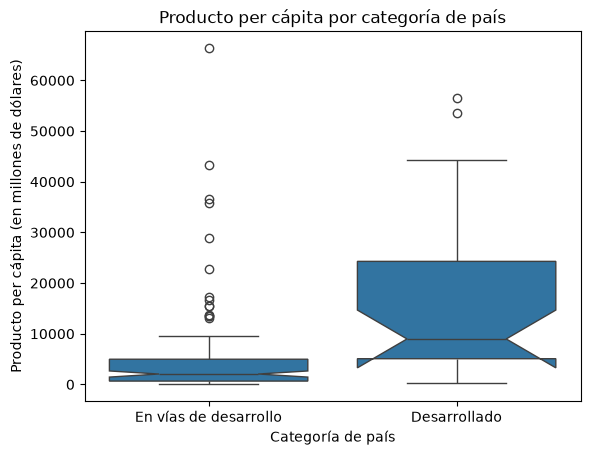

In [128]:
sns.boxplot(x='Developed', y='GDP', data=data_2015, notch=True)
plt.title("Producto per cápita por categoría de país")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylabel("Producto per cápita (en millones de dólares)")
plt.show()

Una intuicion grafica era que si los notch de ambos boxplot coincidian, se podia llegar a demostrar que no hay diferencias significativas entre el PBI per capita de ambos. Como es todo lo contrario (pronunciado), podemos llegar a decir que si existe diferencia, comprobamos estadisticamente.

Tenemos muestras independientes, por lo que podremos usar T-student o Mann-Whitney segun los supuestos de a continuacion.

<h3> T-Student

Tenemos como supuestos:
- Independencia
- Normalidad
- Igualdad de varianzas

<h3> Man-Whitney

Requiere de homogeneidad de varianzas.

<h3> Normalidad

In [129]:
import scipy.stats as stats

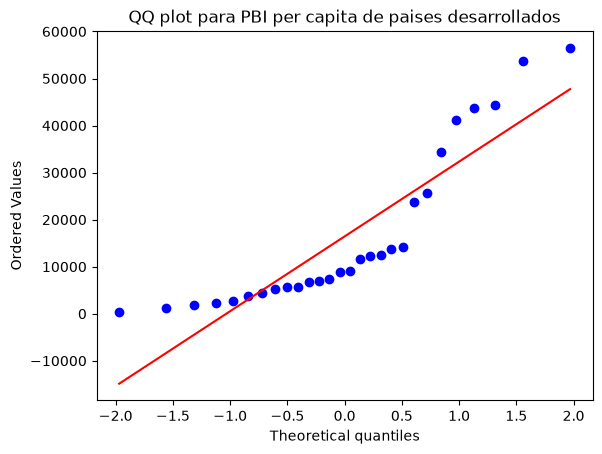

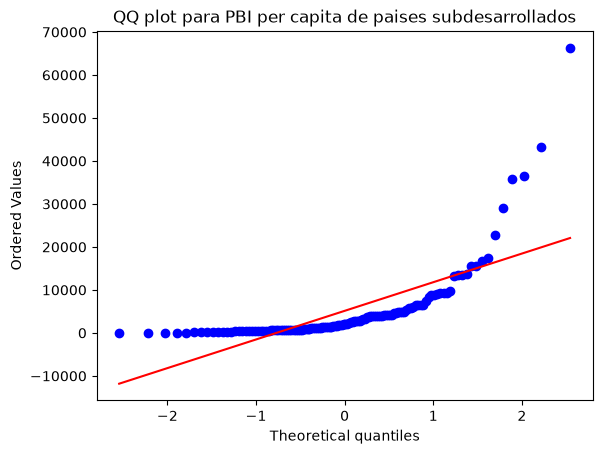

In [130]:
#QQ plot para paises desarrollados
stats.probplot(paises_desarrollados['GDP'], dist='norm', plot=plt)
plt.title('QQ plot para PBI per capita de paises desarrollados')
plt.show()

stats.probplot(paises_subdesarrollados['GDP'], dist='norm', plot=plt)
plt.title('QQ plot para PBI per capita de paises subdesarrollados')
plt.show()


Podemos asegurar practicamente que ambas muestras no siguen una distribucion normal, pero comprobamos con Shapiro-Wilks. Este tiene como hipotesis nula la normalidad de los datos, por lo que si el p-valor es menor a 0.05 estamos ante datos que no siguen una distribucion normal.

In [131]:
from scipy.stats import shapiro

stat, p = shapiro(paises_desarrollados['GDP'])
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.800, p-valor=0.000


In [ ]:
stat, p = shapiro(paises_subdesarrollados['GDP'])
print(f"Test de Shapiro-Wilk para países subdesarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.540, p-valor=0.000


<h3> Homocedasticidad

Usamos el test de Levene que tiene como hipotesis nula la igualdad de varianzas, por lo que si el p-valor es menor a 0.05 las varianzas seran significativamente diferentes.

In [133]:
stat, p = stats.levene(paises_desarrollados['GDP'], paises_subdesarrollados['GDP'])
print(f"Test de Levene para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")


Test de Levene para GDP_per_capita: Estadístico=13.753, p-valor=0.000


Dado que no cumplimos ningun supuesto para ni T-student ni Mann-Whitney, usamos Kruskal-Wallis

<h3> Kruskal-Wallis

Tiene como hipotesis nula es que no existen diferencias significativas entre los dos grupos, por lo que si el p-valor es menor a 0.05 tenemos que si existen diferencias significativas.

In [135]:
stat, p = stats.kruskal(paises_desarrollados['GDP'], paises_subdesarrollados['GDP'])
print(f"Test de Kruskal-Wallis para GDP_per_capita: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para GDP_per_capita: Estadístico=23.281, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el GDP_per_capita entre países desarrollados y en vías de desarrollo.


Inciso c

Comprobar gráfica y estadísticamente si los países en vías de desarrollo gastan un menor porcentaje de su producto bruto en salud que los países desarrollados. Seleccionar el mejor test en función del objetivo y el cumplimiento de los supuestos.

In [161]:
for i in range(df['Year'].min(), df['Year'].max()+1):
    print(f"Anio {i}: {df[df['Year'] == i]['Total expenditure'].isna().sum()} con valores nulos")

Anio 2000: 4 con valores nulos
Anio 2001: 4 con valores nulos
Anio 2002: 4 con valores nulos
Anio 2003: 3 con valores nulos
Anio 2004: 3 con valores nulos
Anio 2005: 3 con valores nulos
Anio 2006: 3 con valores nulos
Anio 2007: 3 con valores nulos
Anio 2008: 3 con valores nulos
Anio 2009: 3 con valores nulos
Anio 2010: 3 con valores nulos
Anio 2011: 3 con valores nulos
Anio 2012: 2 con valores nulos
Anio 2013: 2 con valores nulos
Anio 2014: 2 con valores nulos
Anio 2015: 181 con valores nulos


In [8]:
#nos quedamos con los datos de 2014 ya que tienen menos valores nulos que el de 2015.
data_2014 = df[df['Year'] == 2014]

In [20]:
#separamos por grupos
paises_desarrollados = data_2014[data_2014['Developed'] == 1]
paises_subdesarrollados = data_2014[data_2014['Developed'] == 0]

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
data_2014.columns

Index(['Country', 'Year', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling', 'Developed'],
      dtype='str')

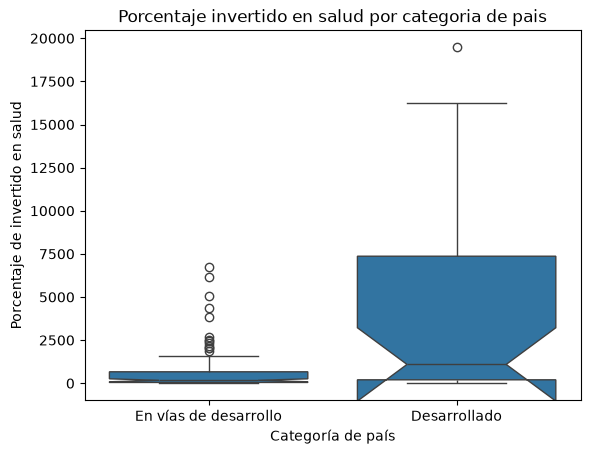

In [16]:
sns.boxplot(x='Developed', y='percentage expenditure', data=data_2014, notch=True)
plt.title("Porcentaje invertido en salud por categoria de pais")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylabel("Porcentaje de invertido en salud")
plt.show()

<h3>Normalidad

In [19]:
import scipy.stats as stats

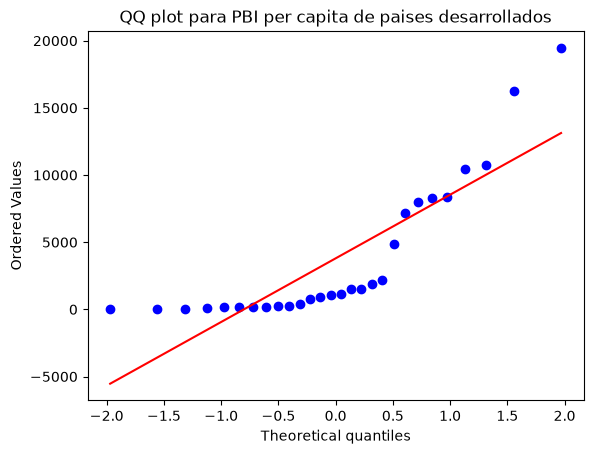

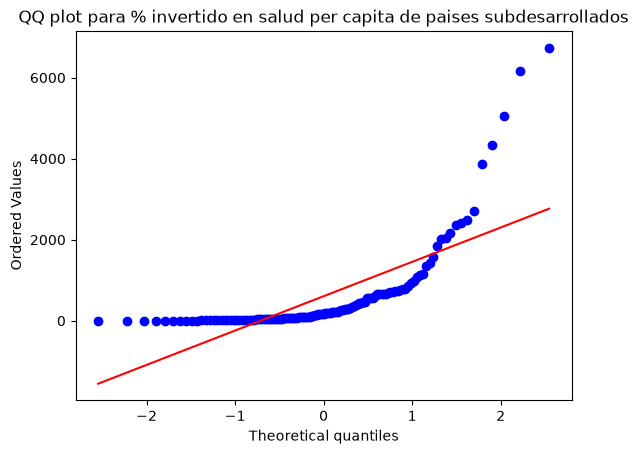

In [23]:
#QQ plot para paises desarrollados
stats.probplot(paises_desarrollados['percentage expenditure'], dist='norm', plot=plt)
plt.title('QQ plot para % invertido en salud per capita de paises subdesarrollados')
plt.show()

stats.probplot(paises_subdesarrollados['percentage expenditure'], dist='norm', plot=plt)
plt.title('QQ plot para % invertido en salud per capita de paises subdesarrollados')
plt.show()

Comprobamos con Shapiro-Wilks. Este tiene como hipotesis nula la normalidad de los datos, por lo que si el p-valor es menor a 0.05 estamos ante datos que no siguen una distribucion normal.

In [24]:
from scipy.stats import shapiro

stat, p = shapiro(paises_desarrollados['percentage expenditure'])
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.737, p-valor=0.000


In [25]:
from scipy.stats import shapiro

stat, p = shapiro(paises_subdesarrollados['percentage expenditure'])
print(f"Test de Shapiro-Wilk para países subdesarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países subdesarrollados: Estadístico=0.556, p-valor=0.000


Vemos claramente que ambos no siguen una distribucion normal

<h3>Homocedasticidad

Tiene como hipotesis nula la igualdad de varianzas, por lo que si el p-valor es menor a 0.05 las varianzas seran significativamente diferentes.

In [26]:
stat, p = stats.levene(paises_desarrollados['percentage expenditure'], paises_subdesarrollados['percentage expenditure'])
print(f"Test de Levene para percentage_expenditure: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para percentage_expenditure: Estadístico=38.779, p-valor=0.000


No tienen igualdad de varianzas.

<h3> Kruskal Wallis

Tiene como hipotesis nula es que no existen diferencias significativas entre los dos grupos, por lo que si el p-valor es menor a 0.05 tenemos que si existen diferencias significativas.

In [28]:
stat, p = stats.kruskal(paises_desarrollados['percentage expenditure'], paises_subdesarrollados['percentage expenditure'])
print(f"Test de Kruskal-Wallis para percentage expenditure: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el percentage expenditure entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el percentage expenditure entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para percentage expenditure: Estadístico=15.263, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el percentage expenditure entre países desarrollados y en vías de desarrollo.


Inciso d

Comprobar gráfica y estadísticamente si los países en vías de desarrollo
tienen una expectativa de vida menor a los desarrollados.

In [33]:
data_2014 = df[df['Year'] == 2014]
#separamos por grupos
paises_desarrollados = data_2014[data_2014['Developed'] == 1]
paises_subdesarrollados = data_2014[data_2014['Developed'] == 0]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

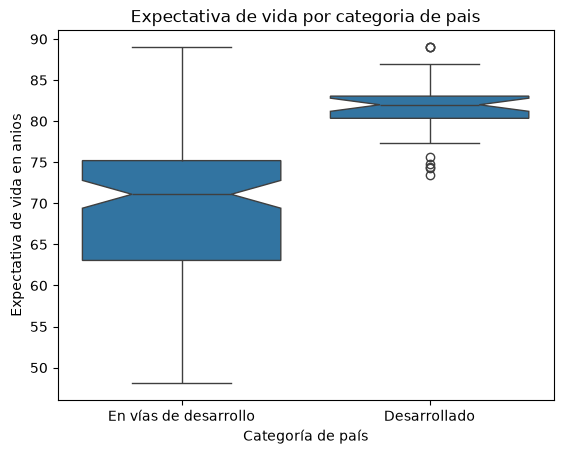

In [36]:
sns.boxplot(x='Developed', y='Life expectancy ', data=data_2014, notch=True)
plt.title("Expectativa de vida por categoria de pais")
plt.xlabel("Categoría de país")
plt.xticks(ticks=[0, 1], labels=["En vías de desarrollo", "Desarrollado"])
plt.ylabel("Expectativa de vida en anios")
plt.show()

Una intuicion grafica es que los paises desarrollados tienen una expectativa de vida mayor y mas estable a diferencia de los paises en vias de desarrollo.

<h3> Normalidad

In [37]:
import scipy.stats as stats

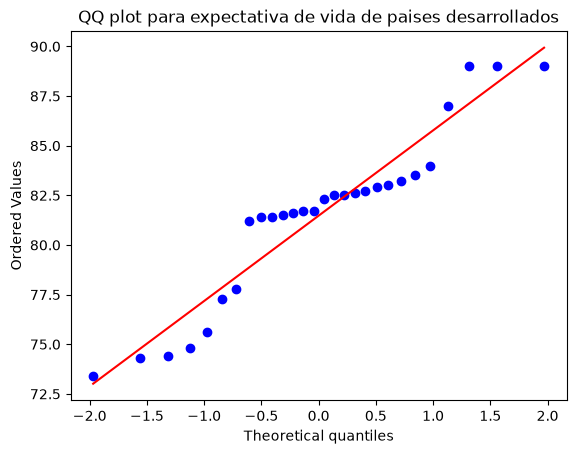

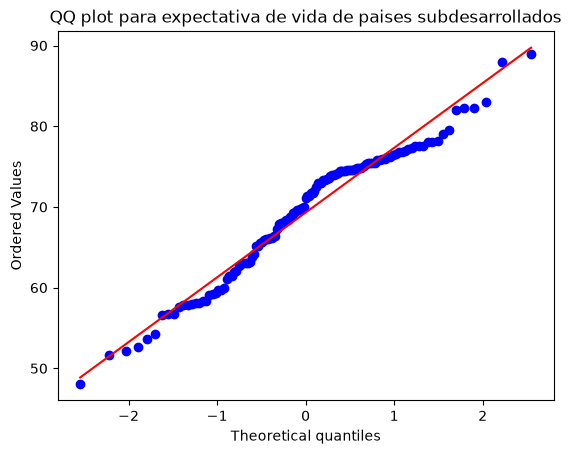

In [39]:
#QQ plot para paises desarrollados
stats.probplot(paises_desarrollados['Life expectancy '], dist='norm', plot=plt)
plt.title('QQ plot para expectativa de vida de paises desarrollados')
plt.show()

stats.probplot(paises_subdesarrollados['Life expectancy '], dist='norm', plot=plt)
plt.title('QQ plot para expectativa de vida de paises subdesarrollados')
plt.show()

<h4> Shapiro

Este tiene como hipotesis nula la normalidad de los datos, por lo que si el p-valor es menor a 0.05 estamos ante datos que no siguen una distribucion normal.

In [40]:
from scipy.stats import shapiro

stat, p = shapiro(paises_desarrollados['Life expectancy '])
print(f"Test de Shapiro-Wilk para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países desarrollados: Estadístico=0.910, p-valor=0.020


In [41]:
stat, p = shapiro(paises_subdesarrollados['Life expectancy '])
print(f"Test de Shapiro-Wilk para países subdesarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para países subdesarrollados: Estadístico=0.968, p-valor=0.005


<h3> Homocedasticidad

Tiene como hipotesis nula la igualdad de varianzas, por lo que si el p-valor es menor a 0.05 las varianzas seran significativamente diferentes.

In [42]:
stat, p = stats.levene(paises_desarrollados['Life expectancy '], paises_subdesarrollados['Life expectancy '])
print(f"Test de Levene para expectativa de vida: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para expectativa de vida: Estadístico=14.131, p-valor=0.000


<h3> Kruskal-Wallis

Tiene como hipotesis nula es que no existen diferencias significativas entre los dos grupos, por lo que si el p-valor es menor a 0.05 tenemos que si existen diferencias significativas.

In [44]:
stat, p = stats.kruskal(paises_desarrollados['Life expectancy '], paises_subdesarrollados['Life expectancy '])
print(f"Test de Kruskal-Wallis para expectativa de vida: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la expectativa de vida entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la expectativa de vida entre países desarrollados y en vías de desarrollo.")

Test de Kruskal-Wallis para expectativa de vida: Estadístico=47.228, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en la expectativa de vida entre países desarrollados y en vías de desarrollo.


Inciso e

¿Hay una relación entre la combinación de las variables producto per cápita y
porcentaje del producto per cápita invertido en salud y la expectativa de vida?
Seleccionar la mejor estrategia para aproximar esta conclusión.